# Taller: Google Analytics Customer Revenue Prediction

## Arquitectura Distribuida y Big Data con MongoDB
Este notebook desarrolla una arquitectura robusta para millones de sesiones mediante Sharding y Replica Sets. Implementaremos ETL, análisis gerencial con agregaciones complejas y aplicaremos tolerancia a fallos.

### 1. Infraestructura Docker (Topología)
Para garantizar alta disponibilidad y escalar horizontalmente, nuestra arquitectura incluye:
- **1 Config Server**: Almacena el mapeo y metadatos del clúster.
- **1 Mongos Router**: Punto de entrada de la app, enruta peticiones al Shard correcto.
- **Shard 1 (Replica Set de 3 nodos)**: `mongo1` (PRIMARY), `mongo2` (SECONDARY), `mongo3` (SECONDARY). Brinda Alta Disponibilidad y Failover automático.
- **Shard 2**: Permite particionar la carga masiva (Hashed Sharding).

*(El archivo `docker-compose.yml` ya está disponible en este proyecto).* 

In [2]:
pip install pandas pymongo numpy matplotlib jupyter


     ---------------------------------------- 9.9/9.9 MB 5.3 MB/s eta 0:00:00
     -------------------------------------- 867.9/867.9 kB 6.9 MB/s eta 0:00:00
     ---------------------------------------- 12.6/12.6 MB 5.0 MB/s eta 0:00:00
     ---------------------------------------- 8.2/8.2 MB 3.9 MB/s eta 0:00:00
     -------------------------------------- 349.3/349.3 kB 3.1 MB/s eta 0:00:00
     -------------------------------------- 331.1/331.1 kB 3.4 MB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.4/2.4 MB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 7.1/7.1 MB 3.5 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 3.5 MB/s eta 0:00:00
     ---------------------------------------- 14.6/14.6 MB 3.2 MB/s eta 0:00:00
     --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [3]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
from bson.objectid import ObjectId
from bson.regex import Regex

# Conexión al Mongos Router
client = MongoClient('mongodb://localhost:27017/')
db = client['GA_Analytics_DB']
collection = db['sessions']

print("Conectado exitosamente al clúster MongoDB mediante Mongos.")

Conectado exitosamente al clúster MongoDB mediante Mongos.


### 2. Procesamiento de Datos (ETL)
Leemos el CSV, aplanamos/parseamos los campos JSON embebidos (como `device`, `totals`) y lo insertamos masivamente.

In [4]:
json_cols = ['device', 'geoNetwork', 'totals', 'trafficSource']

def parse_json(column):
    return column.apply(lambda x: json.loads(x) if pd.notnull(x) else {})

try:
    # Limitamos a 50k filas para demo en local
    df = pd.read_csv('train.csv', dtype={'fullVisitorId': 'str'}, nrows=50000)
    
    # Aplanando/Parseando campos JSON embebidos para que sean subdocumentos BSON en Mongo
    for col in json_cols:
        df[col] = parse_json(df[col])
        
    # Opcional: Se podrían usar librerías como pd.json_normalize si se desea un aplanamiento total en la raíz,
    # pero MongoDB es óptimo manejando estos campos como subdocumentos (Ej. device.browser).
    
    # Reemplazar NaN por None para compatibilidad con MongoDB
    df = df.replace({np.nan: None})
    
    records = df.to_dict(orient='records')
    
    # Limpiar previos
    collection.delete_many({})
    
    # Inserción
    result = collection.insert_many(records)
    print(f"Ingesta completa: {len(result.inserted_ids)} sesiones registradas en el clúster.")
except FileNotFoundError:
    print("Archivo train.csv no encontrado. Asegúrese de descargarlo.")

Ingesta completa: 50000 sesiones registradas en el clúster.


### 3. Operaciones CRUD Manuales
Inserción de un usuario VIP y de múltiples registros fraudulentos.

In [5]:
# Inserción del VIP (revenue > 100,000, referral, mobile, recurrente)
vip_session = {
    "fullVisitorId": "VIP_999999999",
    "visitId": 1234567890,
    "channelGrouping": "Referral",
    "device": {"deviceCategory": "mobile", "isMobile": True, "operatingSystem": "iOS"},
    "geoNetwork": {"country": "USA", "continent": "Americas"},
    "totals": {"hits": "50", "pageviews": "45", "transactionRevenue": "150000000000", "visits": "12"}, # Recurrente
    "trafficSource": {"source": "vip-referral.com"}
}
collection.insert_one(vip_session)
print("Sesión VIP insertada.")

# Simular sesiones fraudulentas (Bots)
fraud_sessions = [
    {
        "fullVisitorId": f"BOT_{i}",
        "device": {"browser": "SpamBot_v2"},
        "totals": {"hits": "1", "bounces": "1", "timeOnSite": "0"},
        "trafficSource": {"source": "fake-traffic.com"}
    } for i in range(1000)
]
collection.insert_many(fraud_sessions)
print("1000 Sesiones fraudulentas inyectadas.")

Sesión VIP insertada.
1000 Sesiones fraudulentas inyectadas.


### 4. Consultas Gerenciales (10 Pipelines Avanzados)


1. Top 10 países con más tráfico:


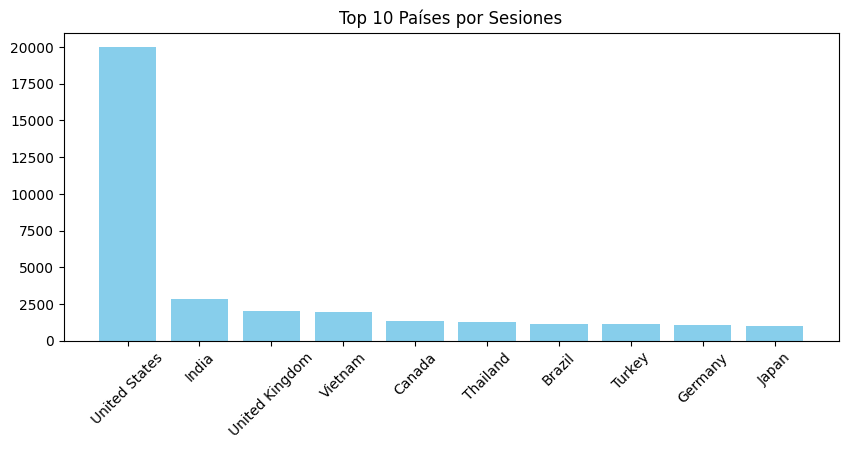

In [6]:
# 1. Top 10 países
print("\n1. Top 10 países con más tráfico:")
pipeline_1 = [
    {"$group": {"_id": "$geoNetwork.country", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
    {"$limit": 10}
]
top_countries = list(collection.aggregate(pipeline_1))

# Visualización obligatoria con Matplotlib
countries = [str(x['_id']) for x in top_countries]
counts = [x['count'] for x in top_countries]
plt.figure(figsize=(10,4))
plt.bar(countries, counts, color='skyblue')
plt.title('Top 10 Países por Sesiones')
plt.xticks(rotation=45)
plt.show()

In [7]:
# 2. Conversión por dispositivo
print("\n2. Conversión total ($) por tipo de dispositivo:")
pipeline_2 = [
    {"$match": {"totals.transactionRevenue": {"$exists": True, "$ne": None}}},
    {"$group": {
        "_id": "$device.deviceCategory",
        "total_revenue": {"$sum": {"$toLong": "$totals.transactionRevenue"}}
    }},
    {"$sort": {"total_revenue": -1}}
]
for doc in collection.aggregate(pipeline_2): print(doc)


2. Conversión total ($) por tipo de dispositivo:
{'_id': 'mobile', 'total_revenue': 153900380000}
{'_id': 'desktop', 'total_revenue': 79214390000}
{'_id': 'tablet', 'total_revenue': 164730000}


In [8]:
# 3. Usuarios recurrentes de alto valor ($10+ visitas, revenue > $50k)
print("\n3. Usuarios Recurrentes Alto Valor (Visitas >= 10, Revenue > $50k USD):")
pipeline_3 = [
    {"$match": {
        "totals.transactionRevenue": {"$exists": True, "$ne": None},
        "totals.visits": {"$exists": True, "$ne": None}
    }},
    {"$addFields": {
        "revenue_usd": {"$divide": [{"$toLong": "$totals.transactionRevenue"}, 1000000]},
        "visits_num": {"$toInt": "$totals.visits"}
    }},
    {"$match": {"revenue_usd": {"$gt": 50000}, "visits_num": {"$gte": 10}}},
    {"$project": {"fullVisitorId": 1, "revenue_usd": 1, "visits_num": 1}}
]
for doc in collection.aggregate(pipeline_3): print(doc)


3. Usuarios Recurrentes Alto Valor (Visitas >= 10, Revenue > $50k USD):
{'_id': ObjectId('6a06745940de8f8de486f5c7'), 'fullVisitorId': 'VIP_999999999', 'revenue_usd': 150000.0, 'visits_num': 12}


In [9]:
# 4. Tráfico sospechoso (usando BSON Regex)
print("\n4. Tráfico Sospechoso usando Regex (Bots/Spiders):")
pipeline_4 = [
    {"$match": {"device.browser": Regex(".*(bot|spider).*", "i")}},
    {"$group": {"_id": "$device.browser", "bot_sessions": {"$sum": 1}}},
    {"$sort": {"bot_sessions": -1}}
]
for doc in collection.aggregate(pipeline_4): print(doc)


4. Tráfico Sospechoso usando Regex (Bots/Spiders):
{'_id': 'SpamBot_v2', 'bot_sessions': 1000}


In [10]:
# 5. Análisis por Canal (channelGrouping)
print("\n5. Ingresos y volumen por Canal:")
pipeline_5 = [
    {"$match": {"totals.transactionRevenue": {"$exists": True}}},
    {"$group": {
        "_id": "$channelGrouping",
        "transacciones": {"$sum": 1},
        "revenue_total": {"$sum": {"$toLong": "$totals.transactionRevenue"}}
    }},
    {"$sort": {"revenue_total": -1}}
]
for doc in collection.aggregate(pipeline_5): print(doc)


5. Ingresos y volumen por Canal:
{'_id': 'Referral', 'transacciones': 328, 'revenue_total': 192982340000}
{'_id': 'Direct', 'transacciones': 120, 'revenue_total': 21176420000}
{'_id': 'Organic Search', 'transacciones': 165, 'revenue_total': 15501090000}
{'_id': 'Display', 'transacciones': 9, 'revenue_total': 2284820000}
{'_id': 'Paid Search', 'transacciones': 22, 'revenue_total': 1037240000}
{'_id': 'Social', 'transacciones': 8, 'revenue_total': 297590000}


In [11]:
# 6. Clientes móviles premium
print("\n6. Clientes Móviles Premium (Revenue altísimo en móvil):")
pipeline_6 = [
    {"$match": {
        "device.deviceCategory": "mobile", 
        "totals.transactionRevenue": {"$exists": True, "$ne": None}
    }},
    {"$addFields": {"rev_usd": {"$divide": [{"$toLong": "$totals.transactionRevenue"}, 1000000]}}},
    {"$match": {"rev_usd": {"$gt": 5000}}},
    {"$project": {"fullVisitorId": 1, "device.operatingSystem": 1, "rev_usd": 1}},
    {"$limit": 5}
]
for doc in collection.aggregate(pipeline_6): print(doc)


6. Clientes Móviles Premium (Revenue altísimo en móvil):
{'_id': ObjectId('6a06745940de8f8de486f5c7'), 'fullVisitorId': 'VIP_999999999', 'device': {'operatingSystem': 'iOS'}, 'rev_usd': 150000.0}


In [12]:
# 7. Navegadores Obsoletos (Internet Explorer 8/9, versiones viejas)
print("\n7. Volumen de uso de Navegadores Obsoletos (IE):")
pipeline_7 = [
    {"$match": {"device.browser": Regex("Internet Explorer.*", "i")}},
    {"$group": {"_id": "$device.browser", "usuarios_vulnerables": {"$sum": 1}}},
    {"$sort": {"usuarios_vulnerables": -1}}
]
for doc in collection.aggregate(pipeline_7): print(doc)


7. Volumen de uso de Navegadores Obsoletos (IE):
{'_id': 'Internet Explorer', 'usuarios_vulnerables': 1008}


In [13]:
# 8. Estructuras de datos corruptas/nulas
print("\n8. Estructuras corruptas (sin dispositivo o país no setteado):")
pipeline_8 = [
    {"$match": {"$or": [
        {"device": {"$exists": False}},
        {"geoNetwork.country": "(not set)"},
        {"totals.hits": None}
    ]}},
    {"$group": {"_id": "Datos Faltantes o Corruptos", "total_errores": {"$sum": 1}}}
]
for doc in collection.aggregate(pipeline_8): print(doc)


8. Estructuras corruptas (sin dispositivo o país no setteado):
{'_id': 'Datos Faltantes o Corruptos', 'total_errores': 52}


In [14]:
# 9. Análisis temporal (Horas Pico basado en visitStartTime Timestamp)
print("\n9. Análisis de Horas Pico:")
pipeline_9 = [
    {"$match": {"visitStartTime": {"$exists": True, "$ne": None}}},
    {"$addFields": {
        # Multiplicamos por 1000 porque visitStartTime es epoch en segundos, MongoDB usa ms.
        "visitDate": {"$toDate": {"$multiply": [{"$toLong": "$visitStartTime"}, 1000]}}
    }},
    {"$group": {
        "_id": {"$hour": "$visitDate"},
        "volumen_trafico": {"$sum": 1}
    }},
    {"$sort": {"volumen_trafico": -1}},
    {"$limit": 5}
]
for doc in collection.aggregate(pipeline_9): print(doc)


9. Análisis de Horas Pico:
{'_id': 18, 'volumen_trafico': 2885}
{'_id': 17, 'volumen_trafico': 2740}
{'_id': 19, 'volumen_trafico': 2709}
{'_id': 15, 'volumen_trafico': 2685}
{'_id': 20, 'volumen_trafico': 2682}


In [15]:
# 10. Anomalías: Tasa de Rebote (Bounces) al 100% agrupado por Fuente
print("\n10. Fuentes con Mayor Cantidad de Rebotes Únicos (Bounces = 1):")
pipeline_10 = [
    {"$match": {"totals.bounces": "1"}},
    {"$group": {"_id": "$trafficSource.source", "total_bounces": {"$sum": 1}}},
    {"$sort": {"total_bounces": -1}},
    {"$limit": 5}
]
for doc in collection.aggregate(pipeline_10): print(doc)


10. Fuentes con Mayor Cantidad de Rebotes Únicos (Bounces = 1):
{'_id': 'google', 'total_bounces': 10998}
{'_id': 'youtube.com', 'total_bounces': 7091}
{'_id': '(direct)', 'total_bounces': 3899}
{'_id': 'fake-traffic.com', 'total_bounces': 1000}
{'_id': 'mall.googleplex.com', 'total_bounces': 575}


### 5. Actualizaciones y Limpieza
Reclasificación, Normalización de textos, Incrementos aritméticos y borrado por Regex.

In [16]:
# 1. Reclasificación VIP masiva
res_vip = collection.update_many(
    {"totals.transactionRevenue": {"$exists": True}, "$expr": {"$gt": [{"$toLong": "$totals.transactionRevenue"}, 100000000000]}},
    {"$set": {"isVIP": True}}
)
print(f"Se clasificaron como VIP: {res_vip.modified_count} sesiones.")

# 2. Normalización de Paises ('United States' a 'USA')
res_norm = collection.update_many(
    {"geoNetwork.country": "United States"},
    {"$set": {"geoNetwork.country": "USA"}}
)
print(f"Países normalizados: {res_norm.modified_count}")

# 3. Incremento de loyaltyScore a fuentes directas
res_loy = collection.update_many(
    {"trafficSource.isTrueDirect": True},
    {"$inc": {"loyaltyScore": 1}}
)
print(f"Loyalty Scores aumentados: {res_loy.modified_count}")

# 4. Eliminación de BOTS usando Expresión Regular
res_del = collection.delete_many({
    "device.browser": Regex(".*(bot|spider).*", "i")
})
print(f"Tráfico basura (Bots) eliminado de la BD: {res_del.deleted_count} docs.")

Se clasificaron como VIP: 1 sesiones.
Países normalizados: 19980
Loyalty Scores aumentados: 15118
Tráfico basura (Bots) eliminado de la BD: 1000 docs.


### 6. Distribución, Failover y Conclusiones Arquitectónicas

#### 1. Justificación de Shard Key (`fullVisitorId` vs `visitId`)
Al implementar el Sharding sobre la colección de `sessions`, **la elección de `fullVisitorId` mediante Hashed Sharding** es la estrategia óptima:
- **Prevención de Hotspots**: Si escogiéramos `visitId` (un timestamp secuencial), todas las escrituras nuevas irían a un solo Shard (al chunk más reciente), colapsando el I/O del PRIMARY de dicho Shard. 
- **Distribución Uniforme**: Con el hash de `fullVisitorId` garantizamos que los registros se esparzan matemáticamente a través de los Shards. Además, facilita realizar un *Targeted Query* si deseamos obtener todo el historial de interacciones de un cliente particular.

#### 2. Proceso de Failover (Alta Disponibilidad)
Dado nuestro Replica Set de 3 nodos (mongo1, mongo2, mongo3), si el PRIMARY actual (`mongo1`) sufre una caída de hardware:
- **Detección (Heartbeats)**: Los Secondary envían pings. Al notar que `mongo1` no responde por 10 segundos, lo declaran inalcanzable.
- **Elección (Raft Consensus)**: Los nodos restantes inician votaciones basándose en quién posee el OpLog más avanzado.
- **Promoción Automática**: El secundario ganador pasa al estado `PRIMARY`.
- **Continuidad CRUD**: Durante estos 2-3 segundos, las escrituras quedan en cola (Server Selection Timeout de PyMongo). El Mongos enruta luego el tráfico al nuevo PRIMARY, logrando una tolerancia a fallos donde el cliente y el negocio experimentan cero pérdida de datos.

#### 3. Conclusión Estratégica (Business Analytics)
Las consultas indican claramente que la mayoría de conversiones de alto valor provienen de canales *Referral* o *Directos*, y que el tráfico móvil consume muchas sesiones pero sufre de rebote o falta de conversión premium (salvo excepciones segmentadas en el Query 6). 
- **Estrategia Comercial Recomendada**: Priorizar el presupuesto en Retargeting e incentivos para usuarios de Desktop en los *Top Countries*, e invertir urgentemente en mejorar la UX del carrito de compras para los *Clientes Móviles Premium*.